# Column Name Overview

### BTCDOWNUSDT@aggTrade 
https://binance-docs.github.io/apidocs/spot/en/#aggregate-trade-streams  
 {   
  "e": "aggTrade",  // Event type  
  "E": 123456789,   // Event time  
  "s": "BNBBTC",    // Symbol  
  "a": 12345,       // Aggregate trade ID  
  "p": "0.001",     // Price  
  "q": "100",       // Quantity  
  "f": 100,         // First trade ID  
  "l": 105,         // Last trade ID  
  "T": 123456785,   // Trade time  
  "m": true,        // Is the buyer the market maker?  
  "M": true         // Ignore  
}  

### BTCDOWNUSDT@ticker
https://binance-docs.github.io/apidocs/spot/en/#individual-symbol-ticker-streams  
 {  
    "e": "24hrTicker",  # Event type  
    "E": 123456789,     # Event time  
    "s": "BNBBTC",      # Symbol  
    "p": "0.0015",      # Price change  
    "P": "250.00",      # Price change percent  
    "w": "0.0018",      # Weighted average price  
    "x": "0.0009",      # First trade(F)-1 price (first trade before the 24hr rolling window)  
    "c": "0.0025",      # Last price  
    "Q": "10",          # Last quantity  
    "b": "0.0024",      # Best bid price  
    "B": "10",          # Best bid quantity  
    "a": "0.0026",      # Best ask price  
    "A": "100",         # Best ask quantity  
    "o": "0.0010",      # Open price  
    "h": "0.0025",      # High price  
    "l": "0.0010",      # Low price  
    "v": "10000",       # Total traded base asset volume  
    "q": "18",          # Total traded quote asset volume  
    "O": 0,             # Statistics open time  
    "C": 86400000,      # Statistics close time  
    "F": 0,             # First trade ID  
    "L": 18150,         # Last trade Id  
    "n": 18151          # Total number of trades  
}

### BTCDOWNUSDT@bookTicker
https://binance-docs.github.io/apidocs/spot/en/#individual-symbol-book-ticker-streams  
{  
  "u":400900217,     // order book updateId  
  "s":"BNBUSDT",     // symbol  
  "b":"25.35190000", // best bid price  
  "B":"31.21000000", // best bid qty  
  "a":"25.36520000", // best ask price  
  "A":"40.66000000"  // best ask qty  
}  

### BTCDOWNUSDT@trade
https://binance-docs.github.io/apidocs/spot/en/#trade-streams  
{  
  "e": "trade",     // Event type  
  "E": 123456789,   // Event time  
  "s": "BNBBTC",    // Symbol  
  "t": 12345,       // Trade ID  
  "p": "0.001",     // Price  
  "q": "100",       // Quantity  
  "b": 88,          // Buyer order ID  
  "a": 50,          // Seller order ID  
  "T": 123456785,   // Trade time  
  "m": true,        // Is the buyer the market maker?  
  "M": true         // Ignore  
}  

---

In [1]:
import gzip
import pandas as pd

# Show all columns in tables
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)

### API Documentation
Binance API documentation overview page  
https://www.binance.com/en/binance-api  


### Example BTCDOWNUSDT:  

Binance BTCDOWNUSDT orderbook:  
https://www.binance.com/en/trade/BTCDOWN_USDT?theme=dark&type=spot  

Binance BTCDOWNUSDT info page:  
https://www.binance.com/en/leveraged-tokens/tokens/allTokens/BTCDOWN  

# Function to create df
Currently column names not working for 'binance-futures'

In [2]:
# Static Variables
# PC path
base_path = "D:/dissertation-data"

# Laptop path
#base_path = "C:/Users/Giancarlo/Desktop/dissertation-data"

new_col_names = {
    'aggTrade' : ['unnamed', 'stream', 'local_timestamp', 'event_type', 'event_time', 'symbol',
                  'aggregated_tradeID', 'price', 'quantity', 'first_tradeID', 'last_tradeID',
                  'trade_time', 'buyer_is_maker', 'best_price_match'],
    'ticker' :   ['unnamed', 'stream', 'local_timestamp', 'event_type', 'event_time', 'symbol', 'price_change',
                  'price_change_percent', 'weighted_avg_price', 'first_trade(F)-1_price', 'last_price', 
                  'last_quantity', 'best_bid_price', 'best_bid_quantity', 'best_ask_price', 'best_ask_quantity',
                  'open_price', 'high_price', 'low_price', 'total_traded_base_asset_vol', 
                  'total_traded_quote_asset_vol', 'stats_open_time', 'first_trade_ID', 'last_trade_ID', 
                  'number_of_trades'],
    'bookTicker':['unnamed', 'stream', 'local_timestamp', 'order_book_update_ID', 'symbol', 'best_bid_price', 
                  'best_bid_qty', 'best_ask_price', 'best_ask_qty'],
    'trade':     ['unnamed', 'stream', 'local_timestamp', 'event_type', 'event_time', 'symbol', 
                  'trade_ID', 'price', 'quantity', 'buyer_order_ID', 'seller_order_ID', 'trade_time', 
                  'buyer_is_maker', 'best_price_match']
}

# Read in specified data and optionally rename columns
def create_df(platform, date, event_type, symbol, rename_cols=True):
    # Generate file path
    file_name = '_'.join([platform, symbol, event_type, date])+'.csv.gz'
    file_path = '/'.join([base_path, platform, date, event_type, file_name])
        
    # Open .csv.gz file as df
    with gzip.open(file_path, 'rt') as gz_file:
        # Open the file as a CSV
        df = pd.read_csv(gz_file)
    
    if rename_cols == True:
        # Replace column names
        # Get current names
        keys = list(df.columns)
        # Get correct names
        values = new_col_names[event_type]
        # combine into dict
        header = dict(zip(keys, values))
        
        # Rename df
        df.rename(columns=header, inplace=True)
    return(df)

In [3]:
# Test
platform='binance'  # 'binance' or 'binance-futures'
date='2021-05-19'  # '2021-05-19' or '2021-04-18'
event_type='trade'  # 'aggTrade' or 'ticker' or 'bookTicker' or 'trade'
symbol='sushiupusdt' # Too many to list, and not all present for all platforms/events - check in folder

create_df(platform, date, event_type, symbol).head()

,unnamed,stream,local_timestamp,event_type,event_time,symbol,trade_ID,price,quantity,buyer_order_ID,seller_order_ID,trade_time,buyer_is_maker,best_price_match
0,0,sushiupusdt@trade,2021-05-19 13:03:48.893120,trade,1621429428232,SUSHIUPUSDT,4216988,0.106,3378.64,70931488,70931654,1621429428231,True,True
1,1,sushiupusdt@trade,2021-05-19 13:03:48.893166,trade,1621429428290,SUSHIUPUSDT,4216989,0.188,53974.87,70931655,70931656,1621429428290,True,True
2,2,sushiupusdt@trade,2021-05-19 13:03:48.893167,trade,1621429428290,SUSHIUPUSDT,4216990,0.106,8218.61,70931488,70931656,1621429428290,True,True
3,3,sushiupusdt@trade,2021-05-19 13:03:48.905873,trade,1621429428337,SUSHIUPUSDT,4216991,0.106,63606.74,70931488,70931657,1621429428337,True,True
4,4,sushiupusdt@trade,2021-05-19 13:03:48.905876,trade,1621429428364,SUSHIUPUSDT,4216992,0.188,8054.91,70931658,70931660,1621429428363,True,True


In [4]:
# Comparing original column names
create_df(platform, date, event_type, symbol, rename_cols=False).head()

,Unnamed: 0,stream,local_timestamp,data.e,data.E,data.s,data.t,data.p,data.q,data.b,data.a,data.T,data.m,data.M
0,0,sushiupusdt@trade,2021-05-19 13:03:48.893120,trade,1621429428232,SUSHIUPUSDT,4216988,0.106,3378.64,70931488,70931654,1621429428231,True,True
1,1,sushiupusdt@trade,2021-05-19 13:03:48.893166,trade,1621429428290,SUSHIUPUSDT,4216989,0.188,53974.87,70931655,70931656,1621429428290,True,True
2,2,sushiupusdt@trade,2021-05-19 13:03:48.893167,trade,1621429428290,SUSHIUPUSDT,4216990,0.106,8218.61,70931488,70931656,1621429428290,True,True
3,3,sushiupusdt@trade,2021-05-19 13:03:48.905873,trade,1621429428337,SUSHIUPUSDT,4216991,0.106,63606.74,70931488,70931657,1621429428337,True,True
4,4,sushiupusdt@trade,2021-05-19 13:03:48.905876,trade,1621429428364,SUSHIUPUSDT,4216992,0.188,8054.91,70931658,70931660,1621429428363,True,True


# BTCDOWNUSDT@aggTrade
Irregular timestamps - whenever trade occured?

In [5]:
df_btcdown_agg = create_df('binance', '2021-05-19', 'aggTrade', 'btcdownusdt')
df_btcdown_agg.head(1)

,unnamed,stream,local_timestamp,event_type,event_time,symbol,aggregated_tradeID,price,quantity,first_tradeID,last_tradeID,trade_time,buyer_is_maker,best_price_match
0,0,btcdownusdt@aggTrade,2021-05-19 00:00:00.892597,aggTrade,1621382400888,BTCDOWNUSDT,6023968,0.08063,2480.46,7368453,7368453,1621382400887,True,True


In [6]:
# What is 'unnamed': Seems like ID but resets at 100,000
# Likely ID within the different download streams, or similar
df_btcdown_agg["unnamed"][99995:100005];

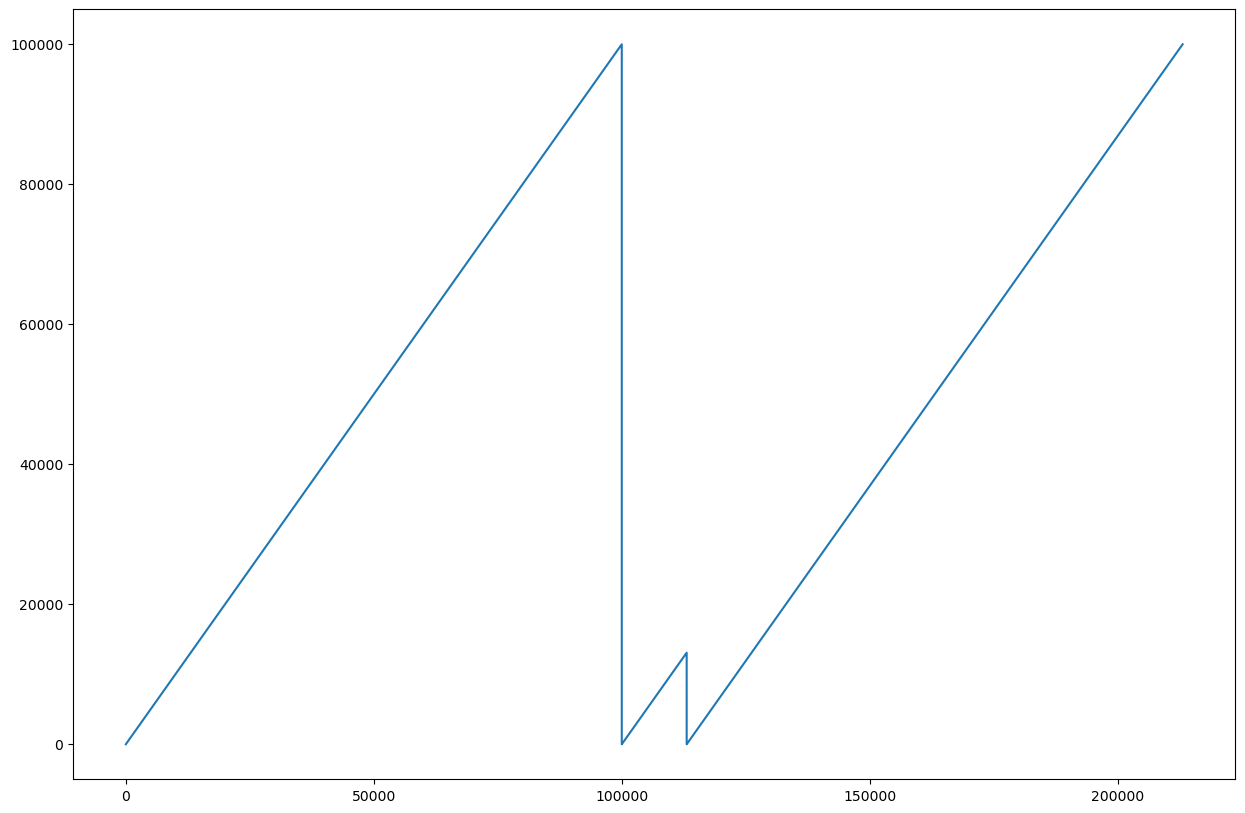

In [7]:
df_btcdown_agg['unnamed'].plot(figsize=(15,10));

# BTCDOWNUSDT@ticker

Regular timestamps every second  

In [8]:
df_btcdown_ticker = create_df('binance', '2021-05-19', 'ticker', 'btcdownusdt')
df_btcdown_ticker.head(1)

,unnamed,stream,local_timestamp,event_type,event_time,symbol,price_change,price_change_percent,weighted_avg_price,first_trade(F)-1_price,last_price,last_quantity,best_bid_price,best_bid_quantity,best_ask_price,best_ask_quantity,open_price,high_price,low_price,total_traded_base_asset_vol,total_traded_quote_asset_vol,stats_open_time,first_trade_ID,last_trade_ID,number_of_trades,data.n
0,0,btcdownusdt@ticker,2021-05-19 00:00:00.531121,24hrTicker,1621382400297,BTCDOWNUSDT,0.0032,4.13,0.075428,0.07707,0.08069,23087.89,0.08037,23113.31,0.08068,1102.51,0.07749,0.08396,0.06714,9.685174e+08,7.305311e+07,1621296000296,1621382400296,7273712,7368452,94741


# BTCDOWNUSDT@bookTicker

In [9]:
df_btcdown_bookTicker = create_df('binance', '2021-05-19', 'bookTicker', 'btcdownusdt')
df_btcdown_bookTicker.head(1)

,unnamed,stream,local_timestamp,order_book_update_ID,symbol,best_bid_price,best_bid_qty,best_ask_price,best_ask_qty
0,0,btcdownusdt@bookTicker,2021-05-19 00:00:00.042894,180387289,BTCDOWNUSDT,0.08037,23113.31,0.08066,37397.16


# BTCDOWNUSDT@trade

In [10]:
df_btcdown_trade = create_df('binance', '2021-05-19', 'trade', 'btcdownusdt')
df_btcdown_trade.head(1)

,unnamed,stream,local_timestamp,event_type,event_time,symbol,trade_ID,price,quantity,buyer_order_ID,seller_order_ID,trade_time,buyer_is_maker,best_price_match
0,0,btcdownusdt@trade,2021-05-19 00:00:00.892157,trade,1621382400888,BTCDOWNUSDT,7368453,0.08063,2480.46,103346087,103346090,1621382400887,True,True


In [11]:
df_btcdown_trade.assign(local_timestamp = lambda df: pd.to_datetime(df.local_timestamp)).sort_values(["local_timestamp"])

,unnamed,stream,local_timestamp,event_type,event_time,symbol,trade_ID,price,quantity,buyer_order_ID,seller_order_ID,trade_time,buyer_is_maker,best_price_match
0,0,btcdownusdt@trade,2021-05-19 00:00:00.892157,trade,1621382400888,BTCDOWNUSDT,7368453,0.08063,2480.46,103346087,103346090,1621382400887,True,True
1,1,btcdownusdt@trade,2021-05-19 00:00:00.905139,trade,1621382400902,BTCDOWNUSDT,7368454,0.08063,2480.46,103346089,103346092,1621382400901,True,True
2,2,btcdownusdt@trade,2021-05-19 00:00:01.000523,trade,1621382400996,BTCDOWNUSDT,7368455,0.08063,2480.46,103346093,103346098,1621382400995,True,True
3,3,btcdownusdt@trade,2021-05-19 00:00:01.000526,trade,1621382400996,BTCDOWNUSDT,7368456,0.08063,2480.46,103346094,103346098,1621382400995,True,True
4,4,btcdownusdt@trade,2021-05-19 00:00:01.000527,trade,1621382400996,BTCDOWNUSDT,7368457,0.08063,2480.46,103346095,103346098,1621382400995,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257803,57803,btcdownusdt@trade,2021-05-19 23:59:57.477074,trade,1621468797471,BTCDOWNUSDT,7626278,0.08740,54702.52,108572963,108572952,1621468797470,False,True
257804,57804,btcdownusdt@trade,2021-05-19 23:59:58.655822,trade,1621468798651,BTCDOWNUSDT,7626279,0.08700,419.18,108572992,108572971,1621468798650,False,True
257805,57805,btcdownusdt@trade,2021-05-19 23:59:58.655833,trade,1621468798651,BTCDOWNUSDT,7626280,0.08707,285.97,108572992,108548901,1621468798650,False,True
257806,57806,btcdownusdt@trade,2021-05-19 23:59:58.671883,trade,1621468798665,BTCDOWNUSDT,7626281,0.08707,443.36,108572992,108572993,1621468798665,True,True


# SUSHI data

In [23]:
sushiup = create_df('binance', '2021-05-19', 'ticker', 'sushiupusdt')

In [24]:
sushiup

,unnamed,stream,local_timestamp,event_type,event_time,symbol,price_change,price_change_percent,weighted_avg_price,first_trade(F)-1_price,last_price,last_quantity,best_bid_price,best_bid_quantity,best_ask_price,best_ask_quantity,open_price,high_price,low_price,total_traded_base_asset_vol,total_traded_quote_asset_vol,stats_open_time,first_trade_ID,last_trade_ID,number_of_trades,data.n
0,0,sushiupusdt@ticker,2021-05-19 00:00:00.762360,24hrTicker,1621382400301,SUSHIUPUSDT,1.845,59.767,4.295864,3.081,4.932,3.04,4.925,1204.82,4.942,165.69,3.087,5.386,3.036,1.014474e+07,4.358043e+07,1621296000185,1621382400185,4014270,4116987,102718
1,1,sushiupusdt@ticker,2021-05-19 00:00:01.682717,24hrTicker,1621382401480,SUSHIUPUSDT,1.838,59.540,4.295873,3.081,4.925,137.86,4.925,1066.96,4.940,165.69,3.087,5.386,3.036,1.014488e+07,4.358111e+07,1621296001416,1621382401416,4014270,4116989,102720
2,2,sushiupusdt@ticker,2021-05-19 00:00:02.683735,24hrTicker,1621382402500,SUSHIUPUSDT,1.838,59.540,4.295873,3.081,4.925,137.86,4.925,499.69,4.940,165.69,3.087,5.386,3.036,1.014488e+07,4.358111e+07,1621296002344,1621382402344,4014270,4116989,102720
3,3,sushiupusdt@ticker,2021-05-19 00:00:03.683045,24hrTicker,1621382403425,SUSHIUPUSDT,1.838,59.540,4.295873,3.081,4.925,137.86,4.925,1049.67,4.938,165.69,3.087,5.386,3.036,1.014488e+07,4.358111e+07,1621296003293,1621382403293,4014270,4116989,102720
4,4,sushiupusdt@ticker,2021-05-19 00:00:04.683331,24hrTicker,1621382404578,SUSHIUPUSDT,1.838,59.540,4.295873,3.081,4.925,137.86,4.925,549.98,4.938,165.69,3.087,5.386,3.036,1.014488e+07,4.358111e+07,1621296004357,1621382404357,4014270,4116989,102720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70699,70699,sushiupusdt@ticker,2021-05-19 23:59:55.699108,24hrTicker,1621468795570,SUSHIUPUSDT,-4.665,-94.721,0.327705,4.932,0.260,57.69,0.259,3759.39,0.261,102857.40,4.925,5.156,0.073,3.130722e+08,1.025954e+08,1621382395569,1621468795569,4116988,4247881,130894
70700,70700,sushiupusdt@ticker,2021-05-19 23:59:56.700521,24hrTicker,1621468795929,SUSHIUPUSDT,-4.665,-94.721,0.327705,4.932,0.260,57.69,0.259,3759.39,0.260,4238.27,4.925,5.156,0.073,3.130722e+08,1.025954e+08,1621382395928,1621468795928,4116988,4247881,130894
70701,70701,sushiupusdt@ticker,2021-05-19 23:59:57.699574,24hrTicker,1621468797560,SUSHIUPUSDT,-4.665,-94.721,0.327705,4.932,0.260,57.69,0.259,3759.39,0.260,5273.18,4.925,5.156,0.073,3.130722e+08,1.025954e+08,1621382397560,1621468797560,4116988,4247881,130894
70702,70702,sushiupusdt@ticker,2021-05-19 23:59:58.718663,24hrTicker,1621468797936,SUSHIUPUSDT,-4.665,-94.721,0.327705,4.932,0.260,57.69,0.259,3759.39,0.260,1034.91,4.925,5.156,0.073,3.130722e+08,1.025954e+08,1621382397936,1621468797936,4116988,4247881,130894


<Axes: >

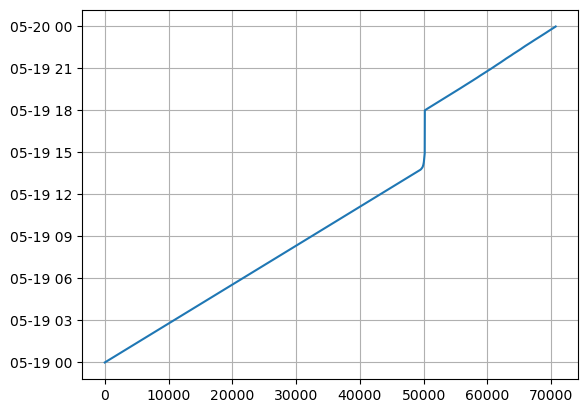

In [25]:
sushiup['local_timestamp'] = pd.to_datetime(sushiup['local_timestamp'])
sushiup = sushiup.sort_values(by=["local_timestamp"])
try:
    sushiup.reset_index(inplace=True)
except:
    pass
sushiup['local_timestamp'].plot(grid=True)

<Axes: >

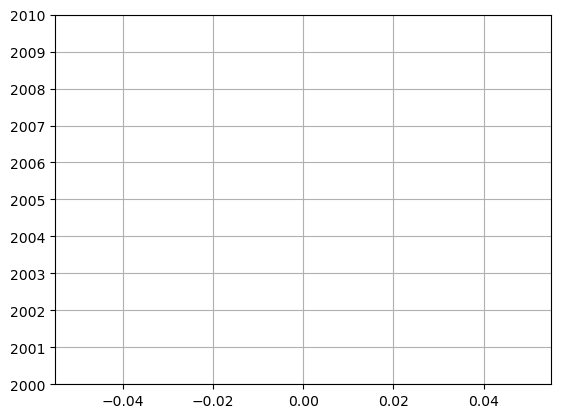

In [26]:
sushiup.loc[104000:110000, 'local_timestamp'].plot(grid=True)

In [16]:
sushidown = create_df('binance', '2021-05-19', 'trade', 'sushidownusdt')

In [17]:
sushidown

,unnamed,stream,local_timestamp,event_type,event_time,symbol,trade_ID,price,quantity,buyer_order_ID,seller_order_ID,trade_time,buyer_is_maker,best_price_match
0,0,sushidownusdt@trade,2021-05-19 00:00:12.488564,trade,1621382412484,SUSHIDOWNUSDT,2397831,0.018984,32702.19,48615267,48615266,1621382412483,False,True
1,1,sushidownusdt@trade,2021-05-19 00:00:12.488565,trade,1621382412484,SUSHIDOWNUSDT,2397832,0.018988,20000.00,48615267,48614971,1621382412483,False,True
2,2,sushidownusdt@trade,2021-05-19 00:00:12.488567,trade,1621382412484,SUSHIDOWNUSDT,2397833,0.019056,15595.94,48615267,48614668,1621382412483,False,True
3,3,sushidownusdt@trade,2021-05-19 00:00:30.265874,trade,1621382430261,SUSHIDOWNUSDT,2397834,0.018715,2533.61,48604644,48615383,1621382430258,True,True
4,4,sushidownusdt@trade,2021-05-19 00:00:33.778918,trade,1621382433770,SUSHIDOWNUSDT,2397835,0.018715,138.04,48604644,48615418,1621382433769,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92003,92003,sushidownusdt@trade,2021-05-19 23:59:47.395521,trade,1621468787375,SUSHIDOWNUSDT,2489835,0.032164,132.18,49881085,49881079,1621468787372,False,True
92004,92004,sushidownusdt@trade,2021-05-19 23:59:48.305801,trade,1621468788299,SUSHIDOWNUSDT,2489836,0.032291,2154.01,49881111,49881109,1621468788298,False,True
92005,92005,sushidownusdt@trade,2021-05-19 23:59:51.362772,trade,1621468791342,SUSHIDOWNUSDT,2489837,0.032301,4460.93,49881130,49881117,1621468791341,False,True
92006,92006,sushidownusdt@trade,2021-05-19 23:59:57.277741,trade,1621468797273,SUSHIDOWNUSDT,2489838,0.032409,462.84,49881207,49881134,1621468797273,False,True


<Axes: >

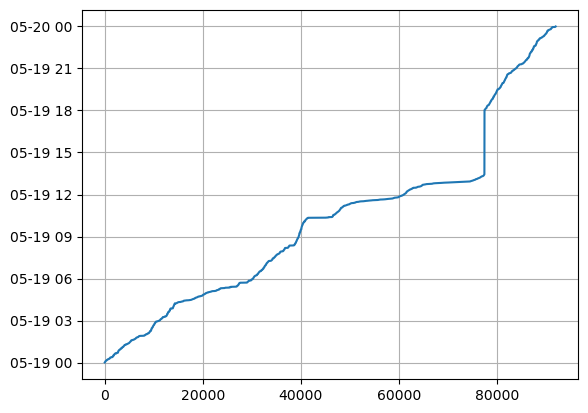

In [18]:
sushidown['local_timestamp'] = pd.to_datetime(sushidown['local_timestamp'])
sushidown['local_timestamp'].plot(grid=True)

In [19]:
ethdown = create_df('binance', '2021-05-19', 'trade', 'ethdownusdt')
ethdown['local_timestamp'] = pd.to_datetime(ethdown['local_timestamp'])
ethdown

,unnamed,stream,local_timestamp,event_type,event_time,symbol,trade_ID,price,quantity,buyer_order_ID,seller_order_ID,trade_time,buyer_is_maker,best_price_match
0,0,ethdownusdt@trade,2021-05-19 12:29:21.560709,trade,1621427361532,ETHDOWNUSDT,5996302,0.001028,30000.00,91341547,91347172,1621427361529,True,True
1,1,ethdownusdt@trade,2021-05-19 12:29:21.560710,trade,1621427361532,ETHDOWNUSDT,5996303,0.001028,337189.99,91341845,91347172,1621427361529,True,True
2,2,ethdownusdt@trade,2021-05-19 12:29:22.107453,trade,1621427362103,ETHDOWNUSDT,5996304,0.001040,187843.29,91347183,91347148,1621427362101,False,True
3,3,ethdownusdt@trade,2021-05-19 12:29:22.981361,trade,1621427362979,ETHDOWNUSDT,5996305,0.001040,292925.94,91347198,91347148,1621427362978,False,True
4,4,ethdownusdt@trade,2021-05-19 12:29:23.193721,trade,1621427363189,ETHDOWNUSDT,5996306,0.001042,18242.55,91347202,91347120,1621427363188,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208345,99995,ethdownusdt@trade,2021-05-19 12:29:21.560499,trade,1621427361532,ETHDOWNUSDT,5996297,0.001030,1907.67,91342039,91347172,1621427361529,True,True
208346,99996,ethdownusdt@trade,2021-05-19 12:29:21.560707,trade,1621427361532,ETHDOWNUSDT,5996298,0.001030,20011.77,91342139,91347172,1621427361529,True,True
208347,99997,ethdownusdt@trade,2021-05-19 12:29:21.560707,trade,1621427361532,ETHDOWNUSDT,5996299,0.001029,1395642.55,91347168,91347172,1621427361529,True,True
208348,99998,ethdownusdt@trade,2021-05-19 12:29:21.560708,trade,1621427361532,ETHDOWNUSDT,5996300,0.001028,38031.27,91340994,91347172,1621427361529,True,True


In [20]:
ethdown = ethdown.sort_values(by=["local_timestamp"])
ethdown.reset_index(inplace=True)

In [21]:
ethdown

,index,unnamed,stream,local_timestamp,event_type,event_time,symbol,trade_ID,price,quantity,buyer_order_ID,seller_order_ID,trade_time,buyer_is_maker,best_price_match
0,108350,0,ethdownusdt@trade,2021-05-19 00:00:04.102157,trade,1621382404094,ETHDOWNUSDT,5896302,0.000646,26416.24,90332929,90333051,1621382404093,True,True
1,108351,1,ethdownusdt@trade,2021-05-19 00:00:10.965735,trade,1621382410962,ETHDOWNUSDT,5896303,0.000646,4635588.42,90332929,90333150,1621382410961,True,True
2,108352,2,ethdownusdt@trade,2021-05-19 00:00:10.965737,trade,1621382410962,ETHDOWNUSDT,5896304,0.000646,38787.89,90333100,90333150,1621382410961,True,True
3,108353,3,ethdownusdt@trade,2021-05-19 00:00:10.966123,trade,1621382410962,ETHDOWNUSDT,5896305,0.000645,14776431.40,90333040,90333150,1621382410961,True,True
4,108354,4,ethdownusdt@trade,2021-05-19 00:00:10.966131,trade,1621382410962,ETHDOWNUSDT,5896306,0.000645,26928323.44,90333096,90333150,1621382410961,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208345,108345,8345,ethdownusdt@trade,2021-05-19 23:59:59.805913,trade,1621468799801,ETHDOWNUSDT,6104649,0.000184,7582208.71,92379816,92380509,1621468799800,True,True
208346,108346,8346,ethdownusdt@trade,2021-05-19 23:59:59.844750,trade,1621468799825,ETHDOWNUSDT,6104650,0.000184,5000000.00,92379816,92380510,1621468799824,True,True
208347,108347,8347,ethdownusdt@trade,2021-05-19 23:59:59.913923,trade,1621468799897,ETHDOWNUSDT,6104651,0.000183,70611.39,92379456,92380516,1621468799896,True,True
208348,108348,8348,ethdownusdt@trade,2021-05-19 23:59:59.913924,trade,1621468799897,ETHDOWNUSDT,6104652,0.000183,263618.65,92379755,92380516,1621468799896,True,True


<Axes: >

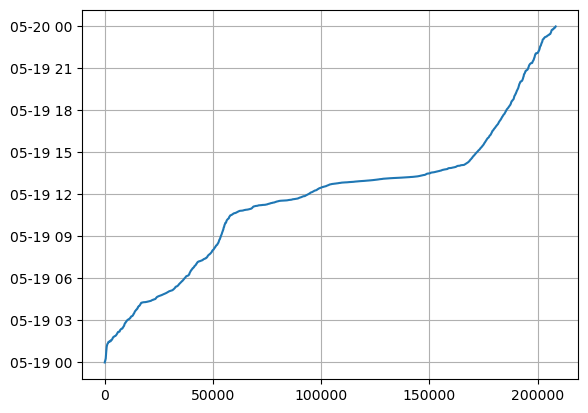

In [22]:
ethdown['local_timestamp'].plot(grid=True)